In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

## Loading Dataset

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

## Merging Both datasets

In [3]:
df = pd.concat([train, test], ignore_index=True)

In [4]:
df

,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
0,1,2011-12-05 11:31:00,Nort,Search,General,Standard,9.00,0.75,0.2782,32.0,817,0.0010,3.34,1.000000,30.0,816.49,119.767811
1,2,2011-04-27 14:01:00,North,Social Media,General,Premium,3.35,3.35,0.0912,61.0,2289,0.0640,4.44,0.366025,90.0,1723.16,119.404661
2,3,2010-11-09 15:20:00,North,Affiliate,General,Budget,2.55,2.55,0.1997,461.0,14697,0.1508,3.31,0.366025,21.0,1151.74,132.009747
3,4,2010-10-03 15:24:00,North,Affiliate,Storage,Premium,2.95,2.95,0.4767,744.0,17578,0.1965,2.87,-0.366025,90.0,3585.85,154.511756
4,5,2011-10-14 09:28:00,North,Search,Lighting,Premium,15.00,1.25,0.3536,226.0,6280,0.0200,7.40,-0.366025,90.0,502.28,128.059924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,23996,2010-10-14 16:14:00,North,Social Media,General,Standard,3.30,1.65,0.0629,591.0,3737,0.0582,3.92,-0.366025,21.0,61.54,NaN
23996,23997,2010-12-01 11:57:00,North,Affiliate,General,Premium,3.48,0.29,0.6000,275.0,8725,0.0291,4.17,1.000000,21.0,3072.86,NaN
23997,23998,2010-03-25 16:33:00,North,Email,General,Premium,21.30,10.65,NaN,91.0,1723,0.0105,NaN,1.000000,60.0,995.19,NaN
23998,23999,2010-10-29 12:07:00,North,Social Media,Storage,Premium,45.00,1.25,0.1014,43.0,1046,0.1632,6.53,-0.366025,14.0,9856.05,NaN


## Basic Data Understanding

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       24000 non-null  int64  
 1   date                     24000 non-null  object 
 2   region                   24000 non-null  object 
 3   channel                  24000 non-null  object 
 4   product_category         24000 non-null  object 
 5   customer_segment         24000 non-null  object 
 6   ad_spend                 23113 non-null  float64
 7   price                    24000 non-null  float64
 8   discount_rate            22965 non-null  float64
 9   market_reach             23079 non-null  float64
 10  impressions              24000 non-null  int64  
 11  click_through_rate       23025 non-null  float64
 12  competition_index        23047 non-null  float64
 13  seasonality_index        24000 non-null  float64
 14  campaign_duration_days

In [6]:
df.describe(include = 'all')

,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
count,24000.000000,24000,24000,24000,24000,24000,23113.000000,24000.000000,22965.000000,23079.000000,24000.000000,23025.000000,23047.00000,24000.000000,22038.000000,22992.000000,18000.000000
unique,NaN,14312,10,11,6,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2011-11-28 15:54:00,North,Social Media,General,Premium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,19,21778,5608,11991,19254,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,12000.500000,NaN,NaN,NaN,NaN,NaN,44.277368,5.547053,0.229198,321.841674,7273.284708,0.056933,4.00224,-0.016105,35.744941,10509.835886,137.204937
std,6928.347566,NaN,NaN,NaN,NaN,NaN,189.884213,21.887603,0.149601,245.478543,7603.662368,0.049310,1.99959,0.919990,27.086134,36421.833930,54.961808
min,1.000000,NaN,NaN,NaN,NaN,NaN,0.001000,0.001000,0.000200,1.000000,-30771.000000,0.000000,0.03000,-1.366025,7.000000,0.001000,0.000000
25%,6000.750000,NaN,NaN,NaN,NaN,NaN,4.950000,1.250000,0.109000,139.000000,2497.000000,0.020300,2.43000,-1.000000,14.000000,570.412500,100.088209
50%,12000.500000,NaN,NaN,NaN,NaN,NaN,12.450000,1.950000,0.202500,269.000000,5115.500000,0.043300,3.86000,0.366025,28.000000,1775.570000,129.113361
75%,18000.250000,NaN,NaN,NaN,NaN,NaN,19.800000,3.750000,0.324100,439.000000,9608.500000,0.079800,5.43000,1.000000,60.000000,5453.470000,164.688454


In [7]:
df.dtypes

id                           int64
date                        object
region                      object
channel                     object
product_category            object
customer_segment            object
ad_spend                   float64
price                      float64
discount_rate              float64
market_reach               float64
impressions                  int64
click_through_rate         float64
competition_index          float64
seasonality_index          float64
campaign_duration_days     float64
customer_lifetime_value    float64
sales_revenue              float64
dtype: object

# Observations from Data Types
date is in object format — needs to be converted to datetime.

region, channel, product_category, customer_segment are categorical — will need encoding.

campaign_duration_days, customer_lifetime_value, and sales_revenue have missing values.

All numerical columns like ad_spend, price, discount_rate, market_reach, etc., are correctly stored as float or int.

region has inconsistency (North vs north) — needs cleaning.

## Missing Value Analysis

In [8]:
df.isnull().sum()

id                            0
date                          0
region                        0
channel                       0
product_category              0
customer_segment              0
ad_spend                    887
price                         0
discount_rate              1035
market_reach                921
impressions                   0
click_through_rate          975
competition_index           953
seasonality_index             0
campaign_duration_days     1962
customer_lifetime_value    1008
sales_revenue              6000
dtype: int64

### # Observation
##### Columns with no missing values:
   - id, date, region, channel, product_category, customer_segment, price, impressions, seasonality_index

##### Columns with few missing values (can use mean/median):
   - ad_spend → 887 missing
   - market_reach → 921 missing
   - competition_index → 953 missing
   - click_through_rate → 975 missing
   - customer_lifetime_value → 1008 missing
   - discount_rate → 1035 missing

##### Columns with high missing values:
   - campaign_duration_days → 1962 missing
   - sales_revenue → 6000 missing (target column — critical)

## Exploratory Data Analysis (EDA)

## Distribution of Numerical Features

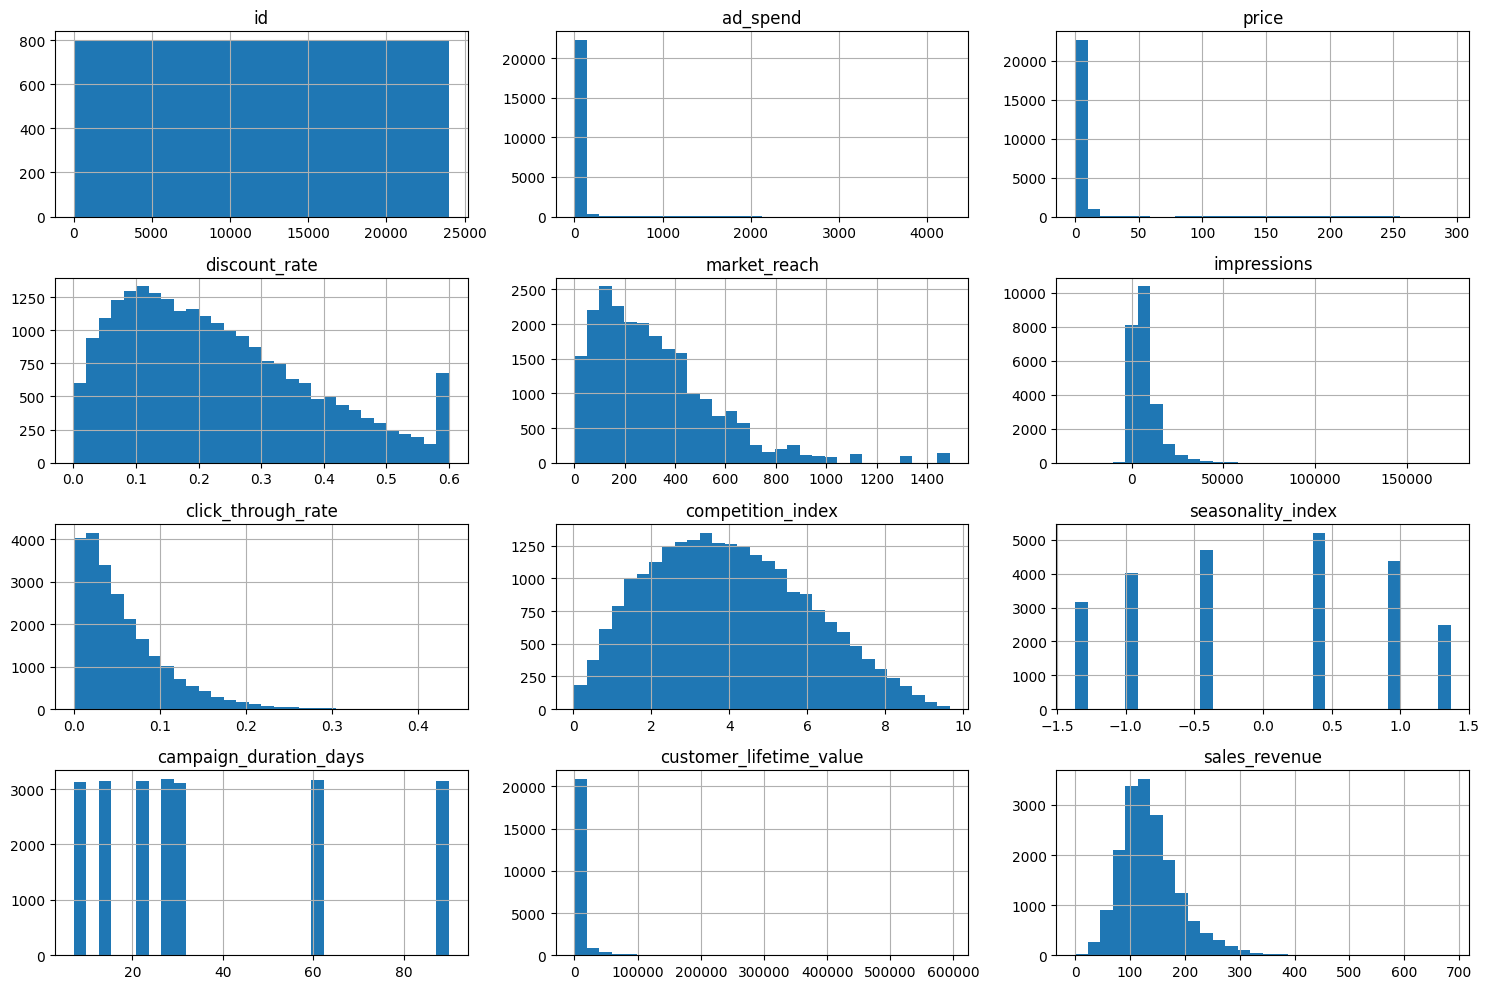

In [9]:
df.hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

### # Observations
  - ad_spend: Most values are very low; few very high → right-skewed.
  - price: Mostly small values; some high values → right-skewed.
  - discount_rate: Spread between 0–0.6; slightly skewed.
  - market_reach: Mostly low reach; few high outliers → right-skewed.
  - impressions: Very right-skewed; many low and few extremely high values.
  - click_through_rate: Mostly very small CTR values; right-skewed.
  - competition_index: Looks almost normally distributed around 4–5.
  - seasonality_index: Only few repeated values → encoded seasonal categories.
  - campaign_duration_days: Only common fixed values (7, 14, 21, 30, etc.).
  - customer_lifetime_value: Mostly low; few extremely high → right-skewed.
  - sales_revenue: Roughly normal with a small right-skew.

## Dividing into Categorical and Numerical Columns

In [10]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

## Correlation Analysis

In [11]:
df[numerical_cols].corr()['sales_revenue'].sort_values(ascending=False)

sales_revenue              1.000000
click_through_rate         0.246271
seasonality_index          0.221127
market_reach               0.178859
impressions                0.128499
campaign_duration_days     0.102231
customer_lifetime_value    0.042255
ad_spend                   0.040729
id                         0.002889
discount_rate             -0.144324
competition_index         -0.188321
price                     -0.205893
Name: sales_revenue, dtype: float64

## Numerical Feature vs Sales Revenue Analysis

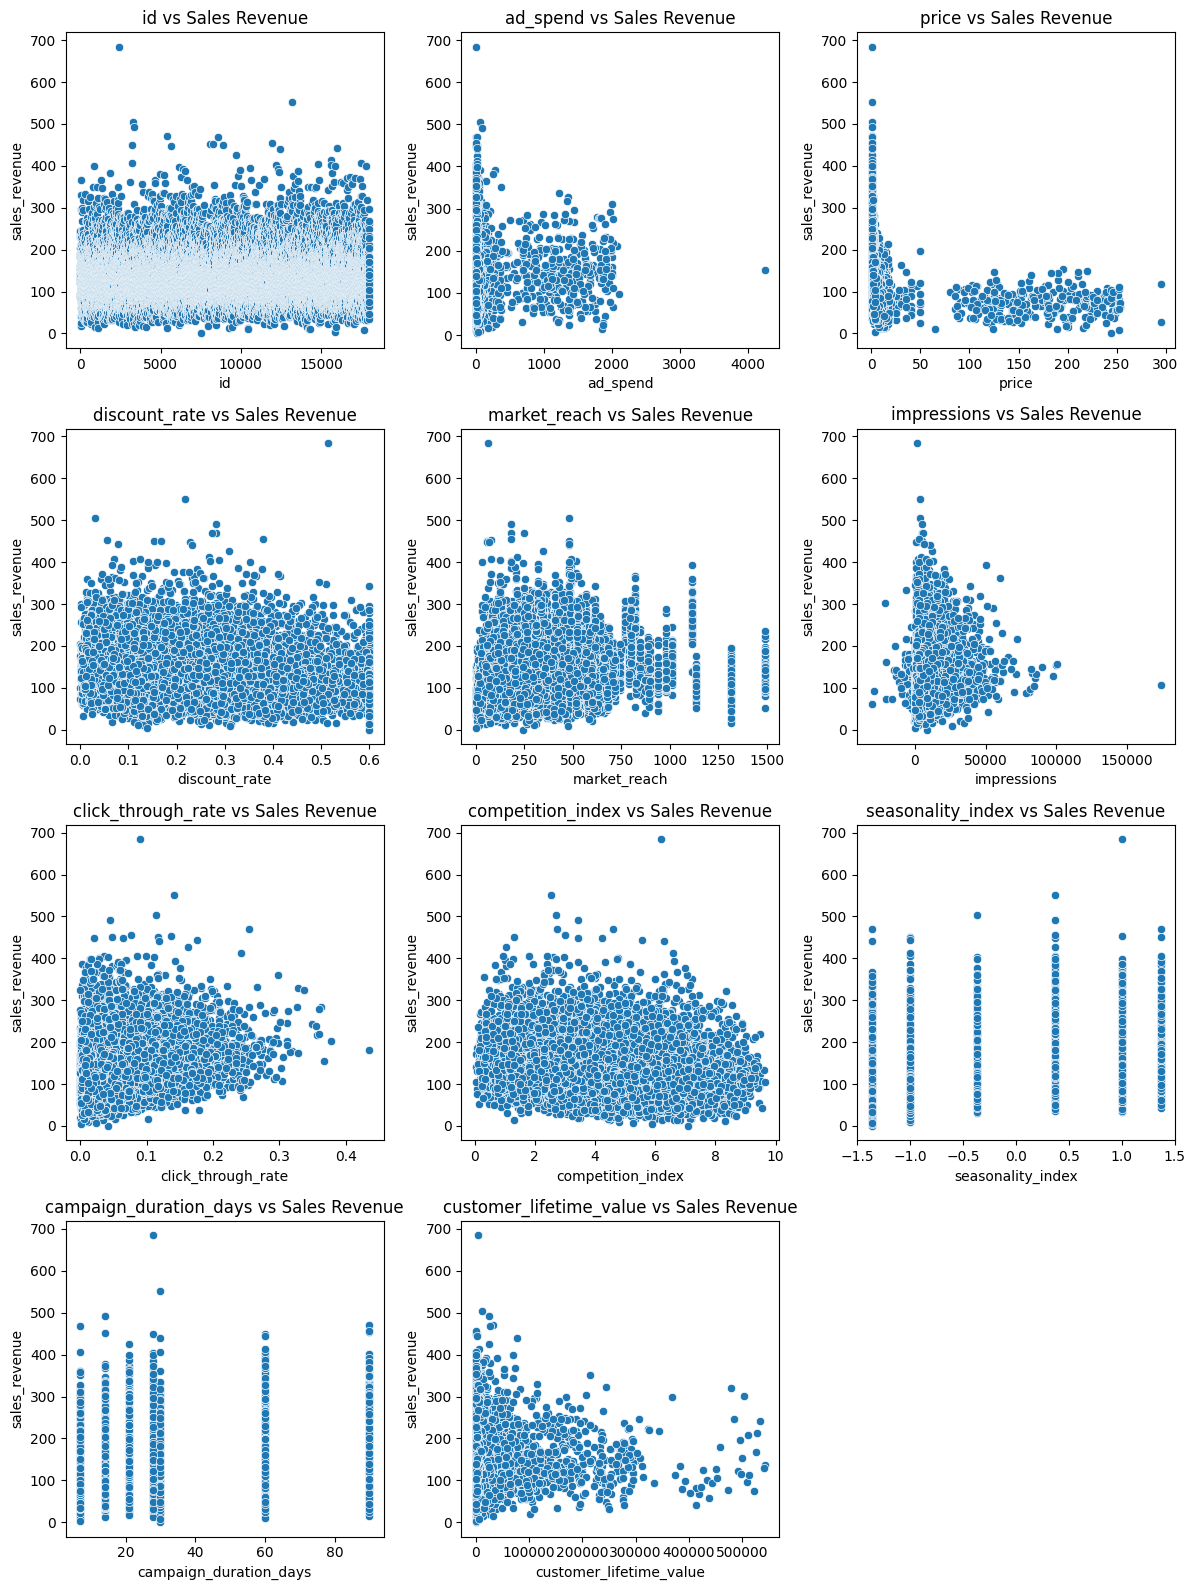

In [12]:
features = [col for col in numerical_cols if col != 'sales_revenue']
n = len(features)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 4*rows))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.scatterplot(x=df[col], y=df['sales_revenue'], ax=axes[i])
    axes[i].set_title(f"{col} vs Sales Revenue")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

 - Click-through rate, seasonality index, and market reach show the strongest positive correlation with sales revenue. This means higher user engagement, seasonal demand, and wider reach contribute to increased revenue.
 - Impressions and campaign duration have a small positive impact, indicating that longer campaigns and more visibility slightly increase revenue.
 - Customer lifetime value, ad spend, and ID show negligible correlation, meaning they do not directly influence revenue in this dataset.
 - Price, competition index, and discount rate show negative correlation, suggesting that increasing price, higher competition, and offering large discounts tend to reduce sales revenue.

## Categorical Variables vs Sales Revenue Analysis

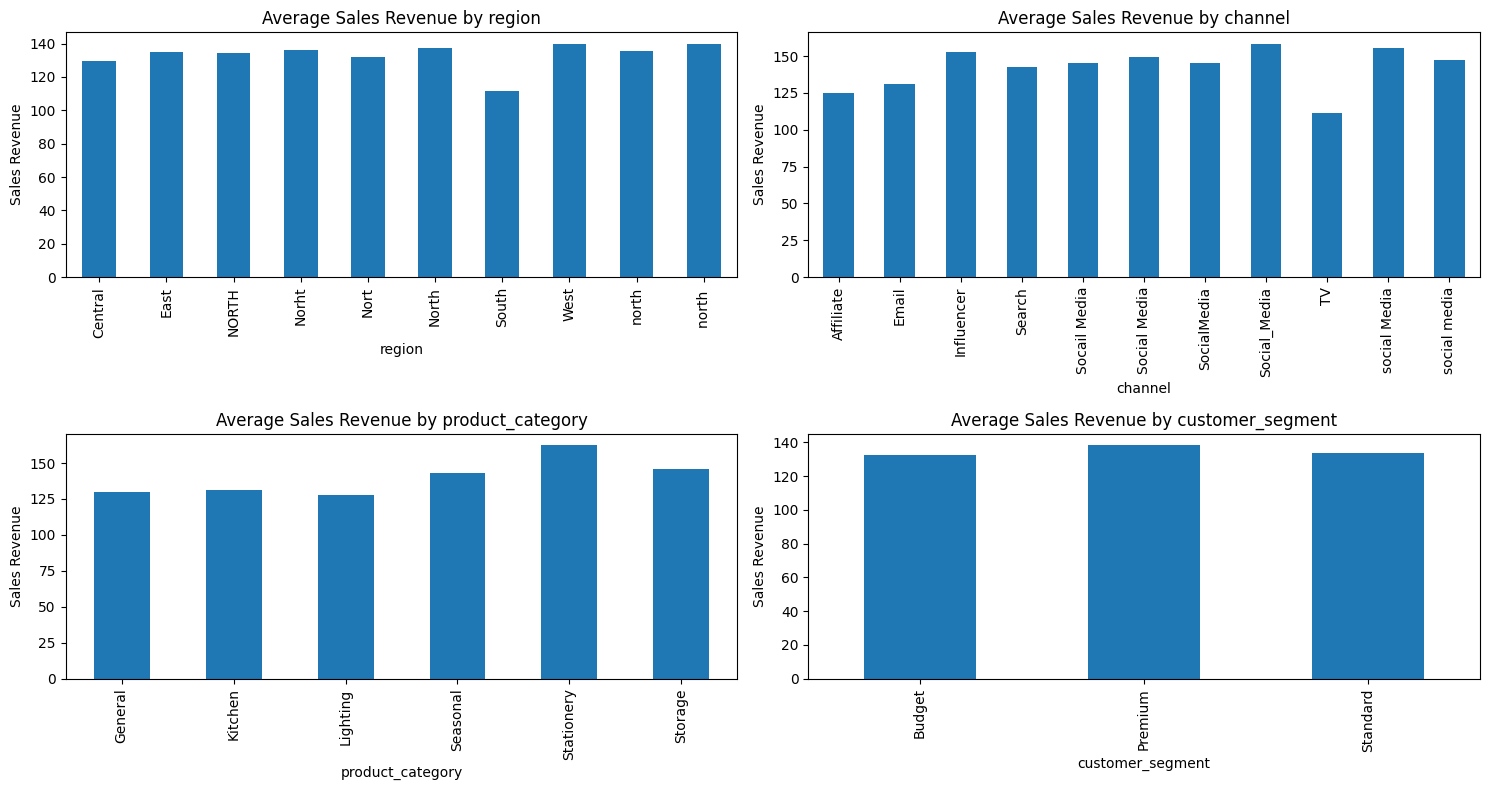

In [13]:
categorical_cols = [col for col in categorical_cols if col != 'date']
n = len(categorical_cols)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df.groupby(col)['sales_revenue'].mean().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f"Average Sales Revenue by {col}")
    axes[i].set_ylabel("Sales Revenue")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### # Observation
- During analysis, I found case-sensitive duplication in categorical values (e.g., “North”, “north”  and "Social Media","social_media").
This caused incorrect grouping in initial plots, so I standardized all categories before continuing EDA.

## Identification of Data Quality Issues in Categorical Features

In [14]:
for col in categorical_cols:
    print(f"\n========== {col} ==========")
    print("Unique Count:", df[col].nunique())
    print("Unique Values:")
    print(df[col].unique())


========== region ==========
Unique Count: 10
Unique Values:
['Nort' 'North' 'north' 'NORTH' 'Central' 'Norht' 'north ' 'East' 'West'
 'South']

========== channel ==========
Unique Count: 11
Unique Values:
['Search' 'Social Media' 'Affiliate' 'Email' 'TV' 'Influencer'
 'Social_Media' 'Socail Media' 'social Media' 'SocialMedia' 'social media']

========== product_category ==========
Unique Count: 6
Unique Values:
['General' 'Storage' 'Lighting' 'Stationery' 'Kitchen' 'Seasonal']

========== customer_segment ==========
Unique Count: 3
Unique Values:
['Standard' 'Premium' 'Budget']


### # Observation ------------------------------
In the dataset, some category names are written in different spellings, cases, and formats.
For example:

 - “North”, “north”, “NORTH”, “north ”, “Nort”, “Norht”
 - “Social Media”, “social media”, “SocialMedia”, “Social_Media”, “Socail Media”
 - Date time is in wrong format

These all refer to the same category, but because they are written differently, pandas treats them as different values.

This is a problem because:

- Analysis will become wrong
- Categories will increase unnecessarily
- Visualizations and insights will be misleading

So, these values must be cleaned and standardized before continuing.

## Date Format Conversion

In [15]:
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True, errors='coerce')

In [16]:
df['date'].dtype

dtype('<M8[ns]')

## Data Cleaning and Preprocessing

## Standardization of Categorical Variables

In [17]:
df['region'] = df['region'].str.strip().str.lower()
df['region'] = df['region'].replace({ 'nort': 'north', 'norht': 'north'})
df['region'] = df['region'].str.title()

In [18]:
df['channel'] = df['channel'].str.strip().str.lower()
df['channel'] = df['channel'].replace({'social media': 'social media', 'socialmedia': 'social media','social_media': 'social media','socail media': 'social media'})
df['channel'] = df['channel'].str.title()

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id                       24000 non-null  int64         
 1   date                     24000 non-null  datetime64[ns]
 2   region                   24000 non-null  object        
 3   channel                  24000 non-null  object        
 4   product_category         24000 non-null  object        
 5   customer_segment         24000 non-null  object        
 6   ad_spend                 23113 non-null  float64       
 7   price                    24000 non-null  float64       
 8   discount_rate            22965 non-null  float64       
 9   market_reach             23079 non-null  float64       
 10  impressions              24000 non-null  int64         
 11  click_through_rate       23025 non-null  float64       
 12  competition_index        23047 n

In [20]:
df = df.dropna(subset=['sales_revenue']).copy()

In [21]:
df.shape

(18000, 17)

## Imputation of Missing Values

In [22]:
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

## Duplicate Records Check

In [23]:
df.duplicated().sum()

np.int64(0)

## Dataset Structure After Cleaning

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18000 entries, 0 to 17999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id                       18000 non-null  int64         
 1   date                     18000 non-null  datetime64[ns]
 2   region                   18000 non-null  object        
 3   channel                  18000 non-null  object        
 4   product_category         18000 non-null  object        
 5   customer_segment         18000 non-null  object        
 6   ad_spend                 18000 non-null  float64       
 7   price                    18000 non-null  float64       
 8   discount_rate            18000 non-null  float64       
 9   market_reach             18000 non-null  float64       
 10  impressions              18000 non-null  int64         
 11  click_through_rate       18000 non-null  float64       
 12  competition_index        18000 non-nu

In [25]:
print(train.shape)
print(test.shape)
print(df.shape)

(18000, 17)
(6000, 16)
(18000, 17)


In [26]:
df_model = df.copy()

## Relationship between features & revenue

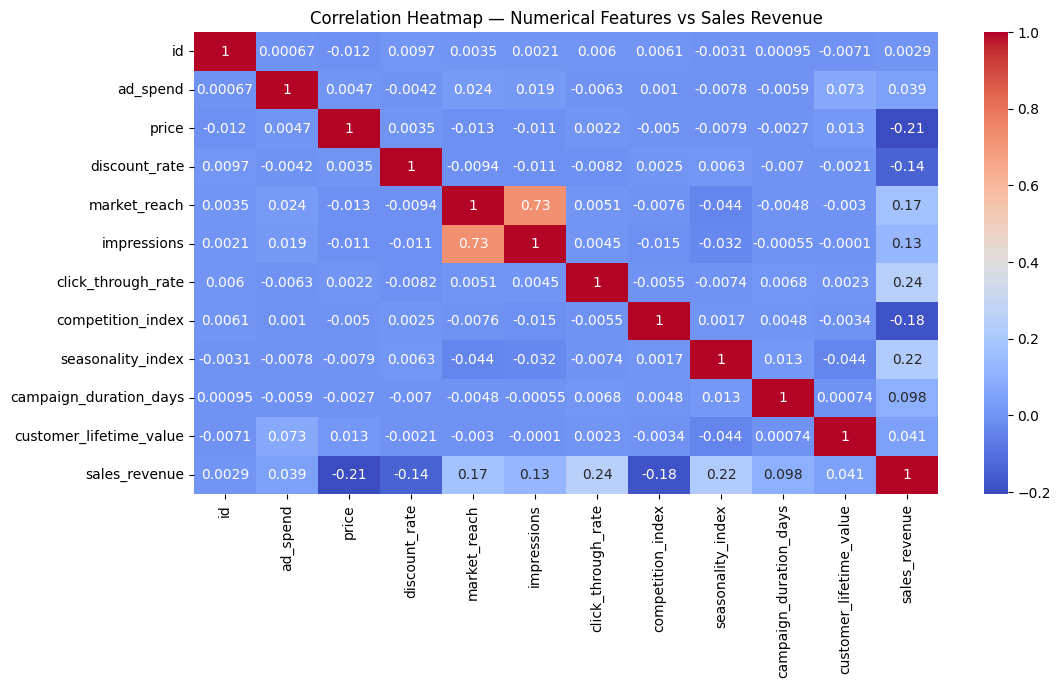

In [27]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True), annot=True,cmap = 'coolwarm')
plt.title("Correlation Heatmap — Numerical Features vs Sales Revenue")
plt.show()

## Observations
##### - Price (-0.21)
- Higher price → lower sales revenue.
##### - Discount Rate (-0.14)
- Discounts do not help revenue much; they may reduce profit.
##### - Market Reach (0.17)
- More market reach → slightly higher revenue.
##### - CTR (Click-Through Rate) (0.24)
- Strongest positive effect on revenue.
- More clicks → more customer interest → more sales.
##### - Seasonality Index (0.22)
- Sales increase during seasonal or festival periods.
##### - Competition Index (-0.18)
- More competition → lower sales.
##### - Customer Lifetime Value (CLV) (0.04)
- Almost no effect on immediate sales revenue.
##### - Ad Spend (0.03)
- Very weak effect; ads may not be targeted well.
##### - Impressions (0.13)
- Weak relationship; seeing the ad does not guarantee purchase.
##### - Market Reach & Impressions (0.73)
- These two are strongly related and provide similar information.

### Summary

##### Most important factors that increase revenue:

- CTR
- Seasonality
- Market Reach

##### Factors that decrease revenue:

- Price
- Competition
- Discount Rate

##### Very weak or no effect:

- CLV
- Ad Spend
- Impressions

## Feature vs Target Trends

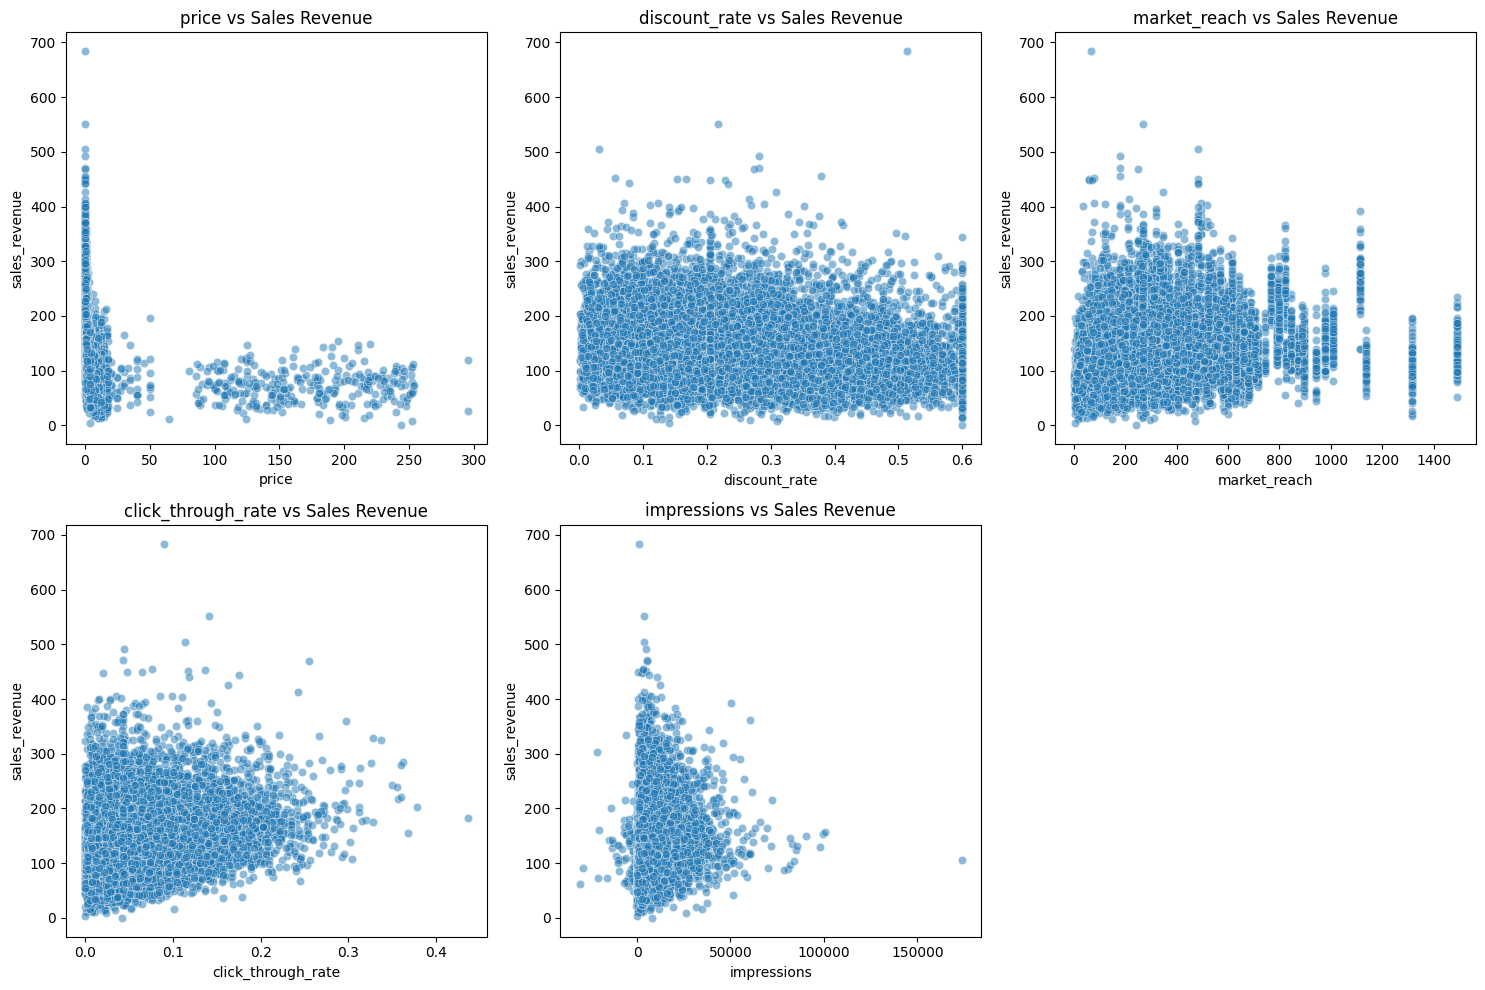

In [28]:
features = ['price', 'discount_rate', 'market_reach', 'click_through_rate', 'impressions']

plt.figure(figsize=(15,10))
for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(data=df, x=col, y='sales_revenue', alpha=0.5)
    plt.title(f'{col} vs Sales Revenue')

plt.tight_layout()
plt.show()

## Marketing Channel Effectiveness

## Sales revenue by channel

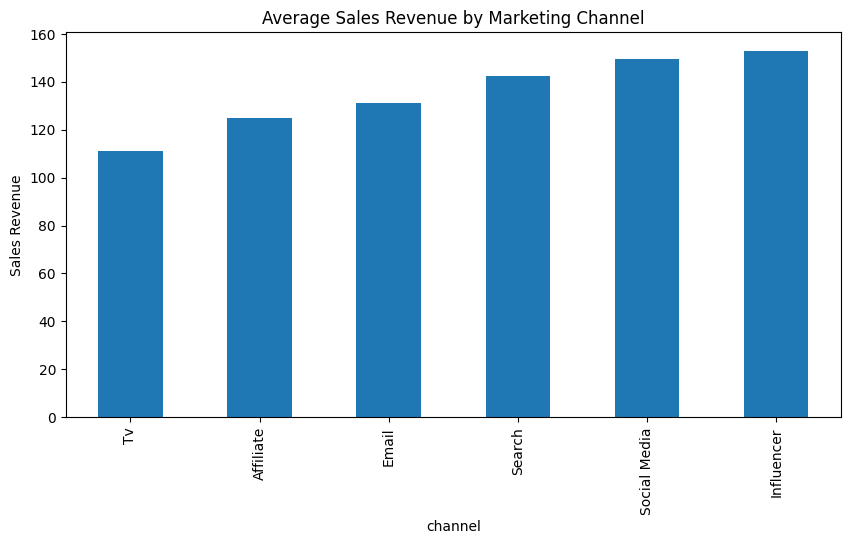

In [29]:
plt.figure(figsize=(10,5))
df.groupby('channel')['sales_revenue'].mean().sort_values().plot(kind='bar')
plt.title("Average Sales Revenue by Marketing Channel")
plt.ylabel("Sales Revenue")
plt.show()

### Observation
- Influencer marketing gives the highest revenue.
- Social Media is the second best channel for sales.
- Search ads also perform well and generate good revenue.
- Email and Affiliate channels give moderate revenue.
- TV ads generate the lowest revenue among all channels.
- Overall, digital channels perform better than traditional channels.
- Businesses should focus more on Influencer, Social Media, and Search campaigns to increase sales.

In [30]:
print("Revenue by Channel:")
print(df.groupby('channel')['sales_revenue'].mean().sort_values())

Revenue by Channel:
channel
Tv              111.201757
Affiliate       124.894378
Email           131.352774
Search          142.301204
Social Media    149.390976
Influencer      153.051931
Name: sales_revenue, dtype: float64


## Impact of Pricing vs Discount

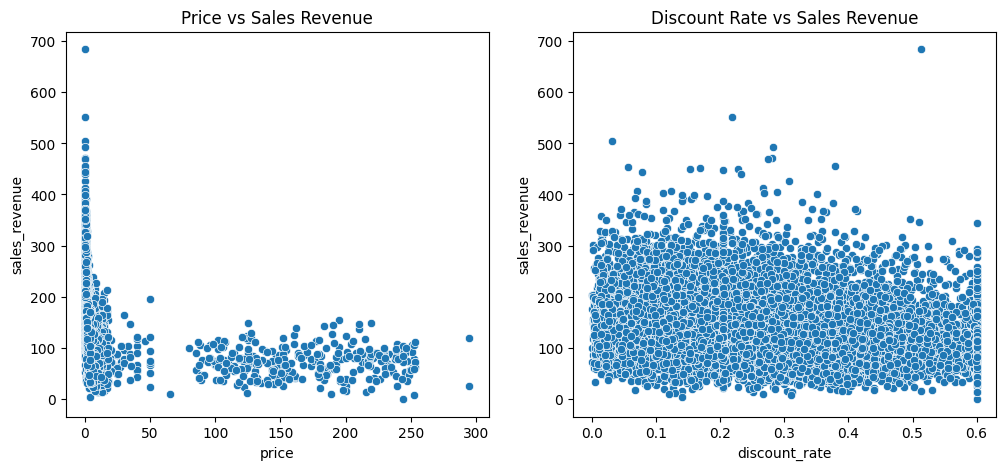

In [31]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.scatterplot(x=df['price'], y=df['sales_revenue'], ax=ax[0])
ax[0].set_title("Price vs Sales Revenue")

sns.scatterplot(x=df['discount_rate'], y=df['sales_revenue'], ax=ax[1])
ax[1].set_title("Discount Rate vs Sales Revenue")

plt.show()

### Price vs Sales Revenue
- When price is very low, sales revenue is high → customers buy more when the product is cheap.
- As price increases, the sales revenue decreases.
- Points are scattered widely at low prices but become more stable at higher prices.
- Overall, the relationship looks like higher price = lower sales revenue.
### Discount Rate vs Sales Revenue
- Sales revenue is spread almost evenly across all discount rates.
- There is no clear trend showing that higher discount leads to higher sales.
- Revenue values remain similar from 0% to 60% discount.
- This indicates discount rate may not strongly influence sales revenue in this dataset.

In [32]:
print("Correlation:")
print("Price:", df['price'].corr(df['sales_revenue']))
print("Discount Rate:", df['discount_rate'].corr(df['sales_revenue']))

Correlation:
Price: -0.20589345449332505
Discount Rate: -0.1416810357116486


### Price vs Sales Revenue
Correlation = -0.20
This is a weak negative correlation.
Meaning: When price increases, sales revenue slightly decreases.
But the effect is not very strong.
### Discount Rate vs Sales Revenue
Correlation = -0.14
This is also a weak negative correlation.
Meaning: Increasing discount is not strongly linked to higher or lower sales revenue.
The impact of discount on revenue is very small.

## ROLE OF CUSTOMER SEGMENTS

##  AVERAGE SALES BY CUSTOMER SEGMENT

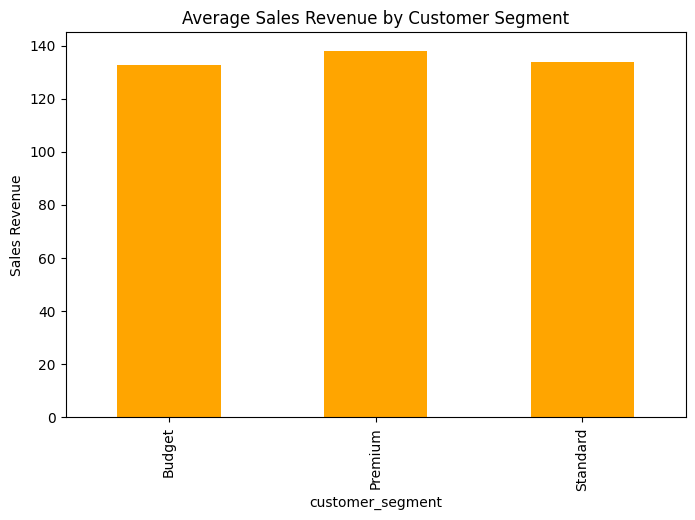

In [33]:
plt.figure(figsize=(8,5))
df.groupby('customer_segment')['sales_revenue'].mean().plot(kind='bar', color='orange')
plt.title("Average Sales Revenue by Customer Segment")
plt.ylabel("Sales Revenue")
plt.show()

### The bar chart compares average sales revenue across three customer segments:
##### Budget, Standard, and Premium.
- Premium customers have the highest average revenue, showing they contribute slightly more than the other segments.
- Budget and Standard customers have similar revenue levels, only slightly lower than Premium.
- Overall, customer segment does not create a very big difference in revenue, but Premium customers still perform the best.

In [34]:
print("Revenue by Customer Segment:")
print(df.groupby('customer_segment')['sales_revenue'].mean())

Revenue by Customer Segment:
customer_segment
Budget      132.576264
Premium     138.107405
Standard    133.813161
Name: sales_revenue, dtype: float64


## Final Insights

In [35]:
corr = df[numerical_cols].corr()['sales_revenue'].sort_values(ascending=False)

print("-----> Strong Positive Influencers:")
print(corr[corr > 0.15])

print("\n-----> Negative Influencers:")
print(corr[corr < -0.10])

print("\n-----> Best Performing Marketing Channel:")
print(df.groupby('channel')['sales_revenue'].mean().idxmax())

print("\n-----> Best Customer Segment:")
print(df.groupby('customer_segment')['sales_revenue'].mean().idxmax())

-----> Strong Positive Influencers:
sales_revenue         1.000000
click_through_rate    0.242433
seasonality_index     0.221127
market_reach          0.173273
Name: sales_revenue, dtype: float64

-----> Negative Influencers:
discount_rate       -0.141681
competition_index   -0.184296
price               -0.205893
Name: sales_revenue, dtype: float64

-----> Best Performing Marketing Channel:
Influencer

-----> Best Customer Segment:
Premium


In [36]:
df_model['year'] = df_model['date'].dt.year
df_model['month'] = df_model['date'].dt.month
df_model['day'] = df_model['date'].dt.day
df_model['weekday'] = df_model['date'].dt.weekday
df_model['hour'] = df_model['date'].dt.hour

In [37]:
df_model = df_model.drop('date', axis=1)

## Encode categorical variables in df_model:

In [38]:
df_model = pd.get_dummies(df_model, columns= ['region', 'channel', 'product_category', 'customer_segment'])

In [39]:
df_model.dtypes

id                               int64
ad_spend                       float64
price                          float64
discount_rate                  float64
market_reach                   float64
impressions                      int64
click_through_rate             float64
competition_index              float64
seasonality_index              float64
campaign_duration_days         float64
customer_lifetime_value        float64
sales_revenue                  float64
year                             int32
month                            int32
day                              int32
weekday                          int32
hour                             int32
region_Central                    bool
region_East                       bool
region_North                      bool
region_South                      bool
region_West                       bool
channel_Affiliate                 bool
channel_Email                     bool
channel_Influencer                bool
channel_Search           

In [40]:
for col in numerical_cols:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1
    
    outliers = df_model[(df_model[col] < Q1 - 1.5*IQR) | (df_model[col] > Q3 + 1.5*IQR)]
    print(col, len(outliers))

id 0
ad_spend 1663
price 1688
discount_rate 0
market_reach 625
impressions 1015
click_through_rate 758
competition_index 2
seasonality_index 0
campaign_duration_days 0
customer_lifetime_value 2240
sales_revenue 574


In [41]:
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)

In [42]:
log_cols = ['ad_spend','price','market_reach','impressions','customer_lifetime_value']

In [43]:
for col in log_cols:
    df_model[col] = df_model[col].clip(lower=0)

In [44]:
for col in log_cols:
    df_model[col] = np.log1p(df_model[col])

In [45]:
df_model.isnull().sum()

id                             0
ad_spend                       0
price                          0
discount_rate                  0
market_reach                   0
impressions                    0
click_through_rate             0
competition_index              0
seasonality_index              0
campaign_duration_days         0
customer_lifetime_value        0
sales_revenue                  0
year                           0
month                          0
day                            0
weekday                        0
hour                           0
region_Central                 0
region_East                    0
region_North                   0
region_South                   0
region_West                    0
channel_Affiliate              0
channel_Email                  0
channel_Influencer             0
channel_Search                 0
channel_Social Media           0
channel_Tv                     0
product_category_General       0
product_category_Kitchen       0
product_ca

In [46]:
df_model['impressions'] = df['impressions']

In [47]:
df_model['impressions'] = np.log1p(df_model['impressions'].clip(lower=0))

In [48]:
df_model.isnull().sum()

id                             0
ad_spend                       0
price                          0
discount_rate                  0
market_reach                   0
impressions                    0
click_through_rate             0
competition_index              0
seasonality_index              0
campaign_duration_days         0
customer_lifetime_value        0
sales_revenue                  0
year                           0
month                          0
day                            0
weekday                        0
hour                           0
region_Central                 0
region_East                    0
region_North                   0
region_South                   0
region_West                    0
channel_Affiliate              0
channel_Email                  0
channel_Influencer             0
channel_Search                 0
channel_Social Media           0
channel_Tv                     0
product_category_General       0
product_category_Kitchen       0
product_ca

## Separate features and target:

In [49]:
x = df_model.drop(['sales_revenue', 'id'], axis=1)
y = df_model['sales_revenue']

In [50]:
df_model

,id,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,...,channel_Tv,product_category_General,product_category_Kitchen,product_category_Lighting,product_category_Seasonal,product_category_Stationery,product_category_Storage,customer_segment_Budget,customer_segment_Premium,customer_segment_Standard
0,1,2.302585,0.559616,0.2782,3.496508,6.706862,0.0010,3.34,1.000000,30.0,...,False,True,False,False,False,False,False,False,False,True
1,2,1.470176,1.470176,0.0912,4.127134,7.736307,0.0640,4.44,0.366025,90.0,...,False,True,False,False,False,False,False,False,True,False
2,3,1.266948,1.266948,0.1997,6.135565,9.595467,0.1508,3.31,0.366025,21.0,...,False,True,False,False,False,False,False,True,False,False
3,4,1.373716,1.373716,0.4767,6.613384,9.774460,0.1965,2.87,-0.366025,90.0,...,False,False,False,False,False,False,True,False,True,False
4,5,2.772589,0.810930,0.3536,5.424950,8.745284,0.0200,7.40,-0.366025,90.0,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17995,17996,1.458615,0.438255,0.2052,7.017506,10.645068,0.0016,8.02,-0.366025,14.0,...,False,False,False,False,False,False,True,False,True,False
17996,17997,1.931521,1.373716,0.1902,1.386294,4.477337,0.0291,5.06,-1.000000,30.0,...,False,False,False,False,False,False,True,False,True,False
17997,17998,2.557227,1.558145,0.0767,5.164786,7.865572,0.0165,0.74,-1.000000,7.0,...,False,True,False,False,False,False,False,False,True,False
17998,17999,1.558145,1.558145,0.0770,5.429346,9.078179,0.0345,4.62,-0.366025,7.0,...,False,False,False,False,False,False,True,False,True,False


## Split into train and validation

In [51]:
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

## Feature Scaling

In [52]:
from sklearn.preprocessing import RobustScaler,StandardScaler
scaler = RobustScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

In [53]:
df_model.isnull().sum()

id                             0
ad_spend                       0
price                          0
discount_rate                  0
market_reach                   0
impressions                    0
click_through_rate             0
competition_index              0
seasonality_index              0
campaign_duration_days         0
customer_lifetime_value        0
sales_revenue                  0
year                           0
month                          0
day                            0
weekday                        0
hour                           0
region_Central                 0
region_East                    0
region_North                   0
region_South                   0
region_West                    0
channel_Affiliate              0
channel_Email                  0
channel_Influencer             0
channel_Search                 0
channel_Social Media           0
channel_Tv                     0
product_category_General       0
product_category_Kitchen       0
product_ca

In [54]:
print("x_train:", x_train.shape)
print("x_val:", x_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

x_train: (14400, 35)
x_val: (3600, 35)
y_train: (14400,)
y_val: (3600,)


In [55]:
import numpy as np
np.isnan(x_train).sum()

np.int64(0)

In [56]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Model Training with Uniform Weights

In [57]:
k_values = range(1, 121) 
results_uniform = []
for i in k_values:
    knn = KNeighborsRegressor(n_neighbors=i,weights = 'uniform')
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_val)
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, y_pred)
    results_uniform.append({'K': i, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2})
    

results_df_uniform = pd.DataFrame(results_uniform)

In [58]:
results_df_uniform

,K,MAE,MSE,RMSE,R2
0,1,32.795846,2124.481704,46.092100,0.318855
1,2,27.613049,1552.157147,39.397426,0.502352
2,3,25.661123,1354.924988,36.809306,0.565588
3,4,24.568691,1265.604467,35.575335,0.594226
4,5,23.977777,1213.483606,34.835092,0.610937
...,...,...,...,...,...
115,116,24.947396,1337.556274,36.572616,0.571157
116,117,24.979203,1339.936194,36.605139,0.570394
117,118,24.990540,1341.088155,36.620870,0.570024
118,119,24.996653,1342.071241,36.634291,0.569709


## Model Training with Distance Weights

In [59]:
k_values = range(1, 121) 
results_distance = []
for i in k_values:
    knn = KNeighborsRegressor(n_neighbors=i,weights = 'distance')
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_val)
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, y_pred)
    results_distance.append({'K': i, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2})
    
# Converting results to DataFrame
results_df_distance = pd.DataFrame(results_distance)

In [60]:
results_df_distance

,K,MAE,MSE,RMSE,R2
0,1,32.795846,2124.481704,46.092100,0.318855
1,2,27.550234,1544.771676,39.303583,0.504720
2,3,25.584882,1347.134077,36.703325,0.568086
3,4,24.477428,1256.310625,35.444472,0.597206
4,5,23.866672,1203.641173,34.693532,0.614092
...,...,...,...,...,...
115,116,24.812393,1324.581503,36.394800,0.575317
116,117,24.842112,1326.860449,36.426096,0.574586
117,118,24.854308,1327.999639,36.441729,0.574221
118,119,24.860685,1328.976174,36.455125,0.573908


In [61]:
best_mae_row_uniform = results_df_uniform.loc[results_df_uniform['MAE'].idxmin()]  
best_r2_row_uniform  = results_df_uniform.loc[results_df_uniform['R2'].idxmax()]   

best_k_uniform = int(best_mae_row_uniform['K']) 
uniform_mae = best_mae_row_uniform['MAE']
uniform_r2  = best_mae_row_uniform['R2']

print("Uniform Weights (Best K based on Minimum Error):")
print(f"Best K = {best_k_uniform}, MAE = {uniform_mae}, R² = {uniform_r2}")

Uniform Weights (Best K based on Minimum Error):
Best K = 13, MAE = 23.158683912232107, R² = 0.6273235712888032


In [62]:
best_mae_row_distance = results_df_distance.loc[results_df_distance['MAE'].idxmin()]  # minimum error
best_r2_row_distance  = results_df_distance.loc[results_df_distance['R2'].idxmax()]   # maximum accuracy

best_k_distance = int(best_mae_row_distance['K'])  # K with minimum error
distance_mae = best_mae_row_distance['MAE']
distance_r2  = best_mae_row_distance['R2']

print("\nDistance Weights (Best K based on Minimum Error):")
print(f"Best K = {best_k_distance}, MAE = {distance_mae}, R² = {distance_r2}")


Distance Weights (Best K based on Minimum Error):
Best K = 13, MAE = 23.019657047518066, R² = 0.6311284895036648


In [63]:
# Compare both models
if (uniform_mae < distance_mae) and (uniform_r2 >= distance_r2):
    best_k = best_k_uniform
    best_weight = 'uniform'

elif (distance_mae < uniform_mae) and (distance_r2 >= uniform_r2):
    best_k = best_k_distance
    best_weight = 'distance'

else:
    # If conflict → prioritize MAE
    if uniform_mae < distance_mae:
        best_k = best_k_uniform
        best_weight = 'uniform'
    else:
        best_k = best_k_distance
        best_weight = 'distance'

print(f"Final Model → K = {best_k}, Weight = {best_weight}")

Final Model → K = 13, Weight = distance


In [64]:
final_model = KNeighborsRegressor(n_neighbors=best_k, weights=best_weight)

final_model.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",13
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Save Model

In [65]:
import pickle

with open('knn_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

In [66]:
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [67]:
with open('columns.pkl', 'wb') as f:
    pickle.dump(x.columns.tolist(), f)